# Example: V1_col_7_4 Activity Trace Heatmap

This compact example loads the 126 matched V1 column neurons from `V1_col_7_4_units_used.csv`, fetches their MICrONS `nda.Activity.trace` values, z-scores each neuron across time, and visualizes the resulting neuron-by-time matrix as a heatmap for presentation.

Note: `nda.Activity.trace` is the spike/activity trace inferred from fluorescence and is the signal used in this example and in the functional correlation analysis.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from microns_phase3 import nda

sns.set_theme(style="white", context="notebook")

SESSION = 7
SCAN_IDX = 4
SCAN_KEY = {"session": SESSION, "scan_idx": SCAN_IDX}

WORKDIR = Path.cwd()
if not (WORKDIR / "outputs_v1_col_7_4").exists() and (WORKDIR.parent / "outputs_v1_col_7_4").exists():
    WORKDIR = WORKDIR.parent
FUNCTIONAL_BASE_OUTDIR = WORKDIR / "outputs_v1_col_7_4" / "functional_correlation" / "2026-05-03"
EXAMPLE_OUTDIR = FUNCTIONAL_BASE_OUTDIR / "example"
CORRELATION_OUTDIR = FUNCTIONAL_BASE_OUTDIR / "correlation"
EXAMPLE_OUTDIR.mkdir(parents=True, exist_ok=True)
UNITS_CSV = CORRELATION_OUTDIR / "V1_col_7_4_units_used.csv"
HEATMAP_PATH = EXAMPLE_OUTDIR / "V1_col_7_4_activity_trace_heatmap.png"
SINGLE_TRACE_PATH = EXAMPLE_OUTDIR / "V1_col_7_4_single_unit_activity_trace_example.png"

print("Working directory:", WORKDIR)
print("Units file:", UNITS_CSV)
print("Functional base output:", FUNCTIONAL_BASE_OUTDIR)
print("Example output directory:", EXAMPLE_OUTDIR)
print("Output heatmap:", HEATMAP_PATH)
print("Single-unit trace plot:", SINGLE_TRACE_PATH)


Connecting root@database:3306
Working directory: /notebooks/workspace
Units file: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_units_used.csv
Functional base output: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03
Example output directory: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/example
Output heatmap: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/example/V1_col_7_4_activity_trace_heatmap.png
Single-unit trace plot: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/example/V1_col_7_4_single_unit_activity_trace_example.png


## Load the 126 matched functional units

In [2]:
units_df = pd.read_csv(UNITS_CSV)
unit_ids = units_df["unit_id"].astype(int).to_numpy()

print("Number of units:", len(unit_ids))
display(units_df[["session", "scan_idx", "unit_id", "pt_root_id"]].head())

Number of units: 126


,session,scan_idx,unit_id,pt_root_id
0,7,4,2158,864691134950156796
1,7,4,2162,864691136126503206
2,7,4,2196,864691135757002450
3,7,4,2197,864691135738969220
4,7,4,2199,864691136058646488


## Fetch activity traces from DataJoint

The analyzed variable is `nda.Activity.trace`. In MICrONS functional-data examples this is described as a spike/activity trace inferred from fluorescence traces.


In [3]:
selected_keys = [
    {"session": SESSION, "scan_idx": SCAN_IDX, "unit_id": int(unit_id)}
    for unit_id in unit_ids
]

selected_activity = nda.Activity & selected_keys
print("Requested units:", len(selected_keys))
print("Activity traces found:", len(selected_activity))

keys, traces = selected_activity.fetch("KEY", "trace", order_by="unit_id")
activity_unit_ids = np.array([key["unit_id"] for key in keys], dtype=int)

trace_lengths = np.array([len(np.asarray(trace).squeeze()) for trace in traces])
print(pd.Series(trace_lengths).describe())

min_len = int(trace_lengths.min())
trace_matrix = np.vstack([
    np.asarray(trace).squeeze()[:min_len]
    for trace in traces
])

print("Trace matrix shape (neurons x frames):", trace_matrix.shape)

Requested units: 126
Activity traces found: 126


count      126.0
mean     40000.0
std          0.0
min      40000.0
25%      40000.0
50%      40000.0
75%      40000.0
max      40000.0
dtype: float64
Trace matrix shape (neurons x frames): (126, 40000)


## Plot one example unit trace

This plots the exact signal used in the correlation analysis for one neuron: `nda.Activity.trace`.


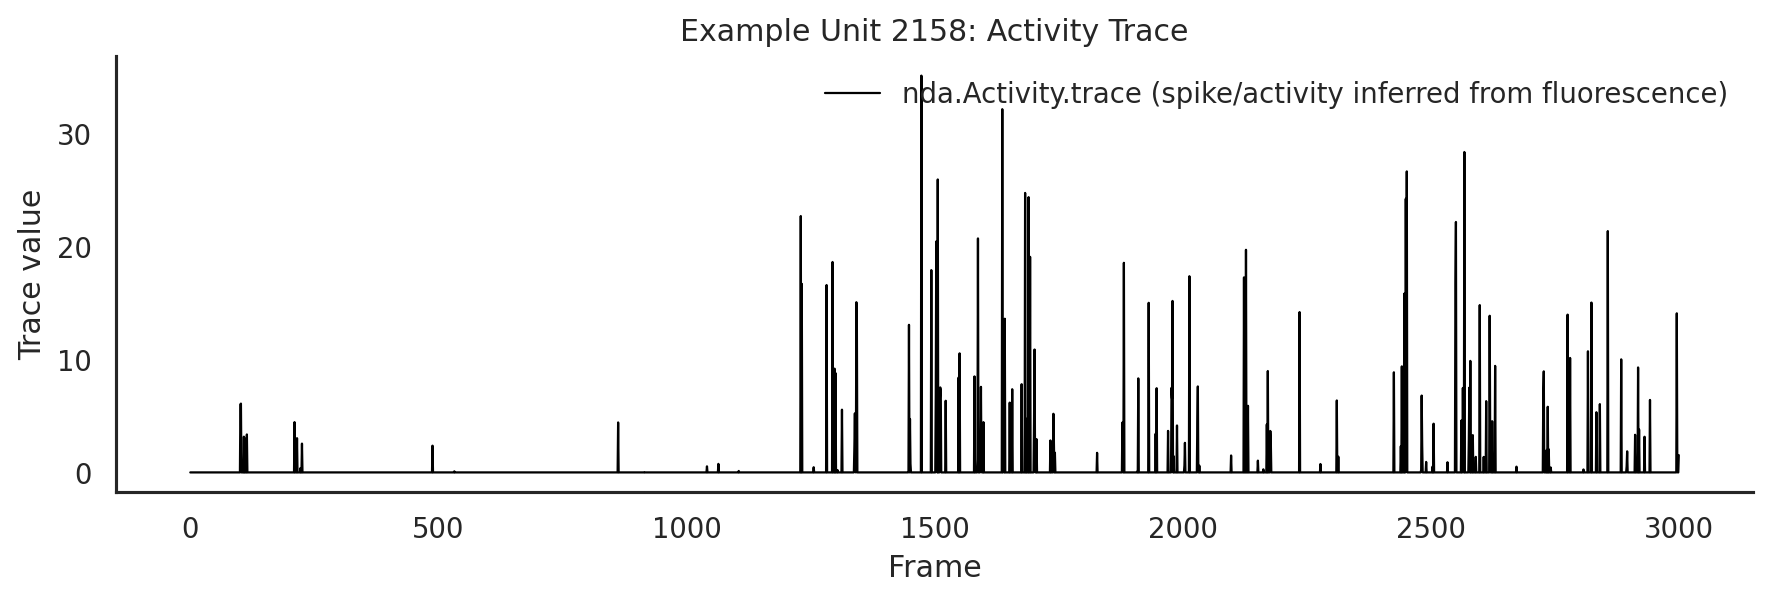

Example unit_id: 2158
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/example/V1_col_7_4_single_unit_activity_trace_example.png


In [4]:
example_idx = 0
example_unit_id = int(activity_unit_ids[example_idx])
example_key = {"session": SESSION, "scan_idx": SCAN_IDX, "unit_id": example_unit_id}
example_activity_trace = np.asarray(traces[example_idx]).squeeze().astype(float)

max_frames_to_plot = min(3000, example_activity_trace.size)
frame_axis = np.arange(max_frames_to_plot)

fig, ax = plt.subplots(figsize=(10, 3.5), dpi=180)
ax.plot(
    frame_axis,
    example_activity_trace[:max_frames_to_plot],
    color="black",
    lw=0.9,
    label="nda.Activity.trace (spike/activity inferred from fluorescence)",
)

# Fluorescence trace overlay intentionally disabled for this example.
# try:
#     example_calcium_trace = np.asarray(
#         (nda.Fluorescence & (nda.ScanUnit & example_key)).fetch1("trace")
#     ).squeeze().astype(float)
#     calcium_plot = example_calcium_trace[:max_frames_to_plot]
#     calcium_plot = calcium_plot / np.nanmax(np.abs(calcium_plot))
#     activity_scale = np.nanmax(np.abs(example_activity_trace[:max_frames_to_plot]))
#     if np.isfinite(activity_scale) and activity_scale > 0:
#         calcium_plot = calcium_plot * activity_scale
#     ax.plot(
#         frame_axis,
#         calcium_plot,
#         color="seagreen",
#         alpha=0.45,
#         lw=0.9,
#         label="nda.Fluorescence.trace (raw calcium fluorescence, scaled)",
#     )
# except Exception as exc:
#     print("Raw fluorescence trace was not plotted:", repr(exc))
ax.set_title(f"Example Unit {example_unit_id}: Activity Trace")
ax.set_xlabel("Frame")
ax.set_ylabel("Trace value")
ax.legend(frameon=False, loc="upper right")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(SINGLE_TRACE_PATH, bbox_inches="tight")
plt.show()

print("Example unit_id:", example_unit_id)
print("Saved:", SINGLE_TRACE_PATH)


## Z-score and downsample for visualization

In [5]:
def zscore_rows(x: np.ndarray) -> np.ndarray:
    x = x.astype(float)
    mean = np.nanmean(x, axis=1, keepdims=True)
    std = np.nanstd(x, axis=1, keepdims=True)
    std[std == 0] = np.nan
    return (x - mean) / std


def bin_timepoints(x: np.ndarray, bin_size: int = 20) -> np.ndarray:
    usable_frames = (x.shape[1] // bin_size) * bin_size
    x = x[:, :usable_frames]
    return x.reshape(x.shape[0], -1, bin_size).mean(axis=2)


z_traces = zscore_rows(trace_matrix)
valid_rows = np.isfinite(z_traces).all(axis=1)
z_traces = z_traces[valid_rows]
plot_unit_ids = activity_unit_ids[valid_rows]

# 40,000 frames is too dense for a slide, so average every 20 frames.
z_traces_binned = bin_timepoints(z_traces, bin_size=20)

print("Binned heatmap matrix shape:", z_traces_binned.shape)

Binned heatmap matrix shape: (126, 2000)


## Plot heatmap

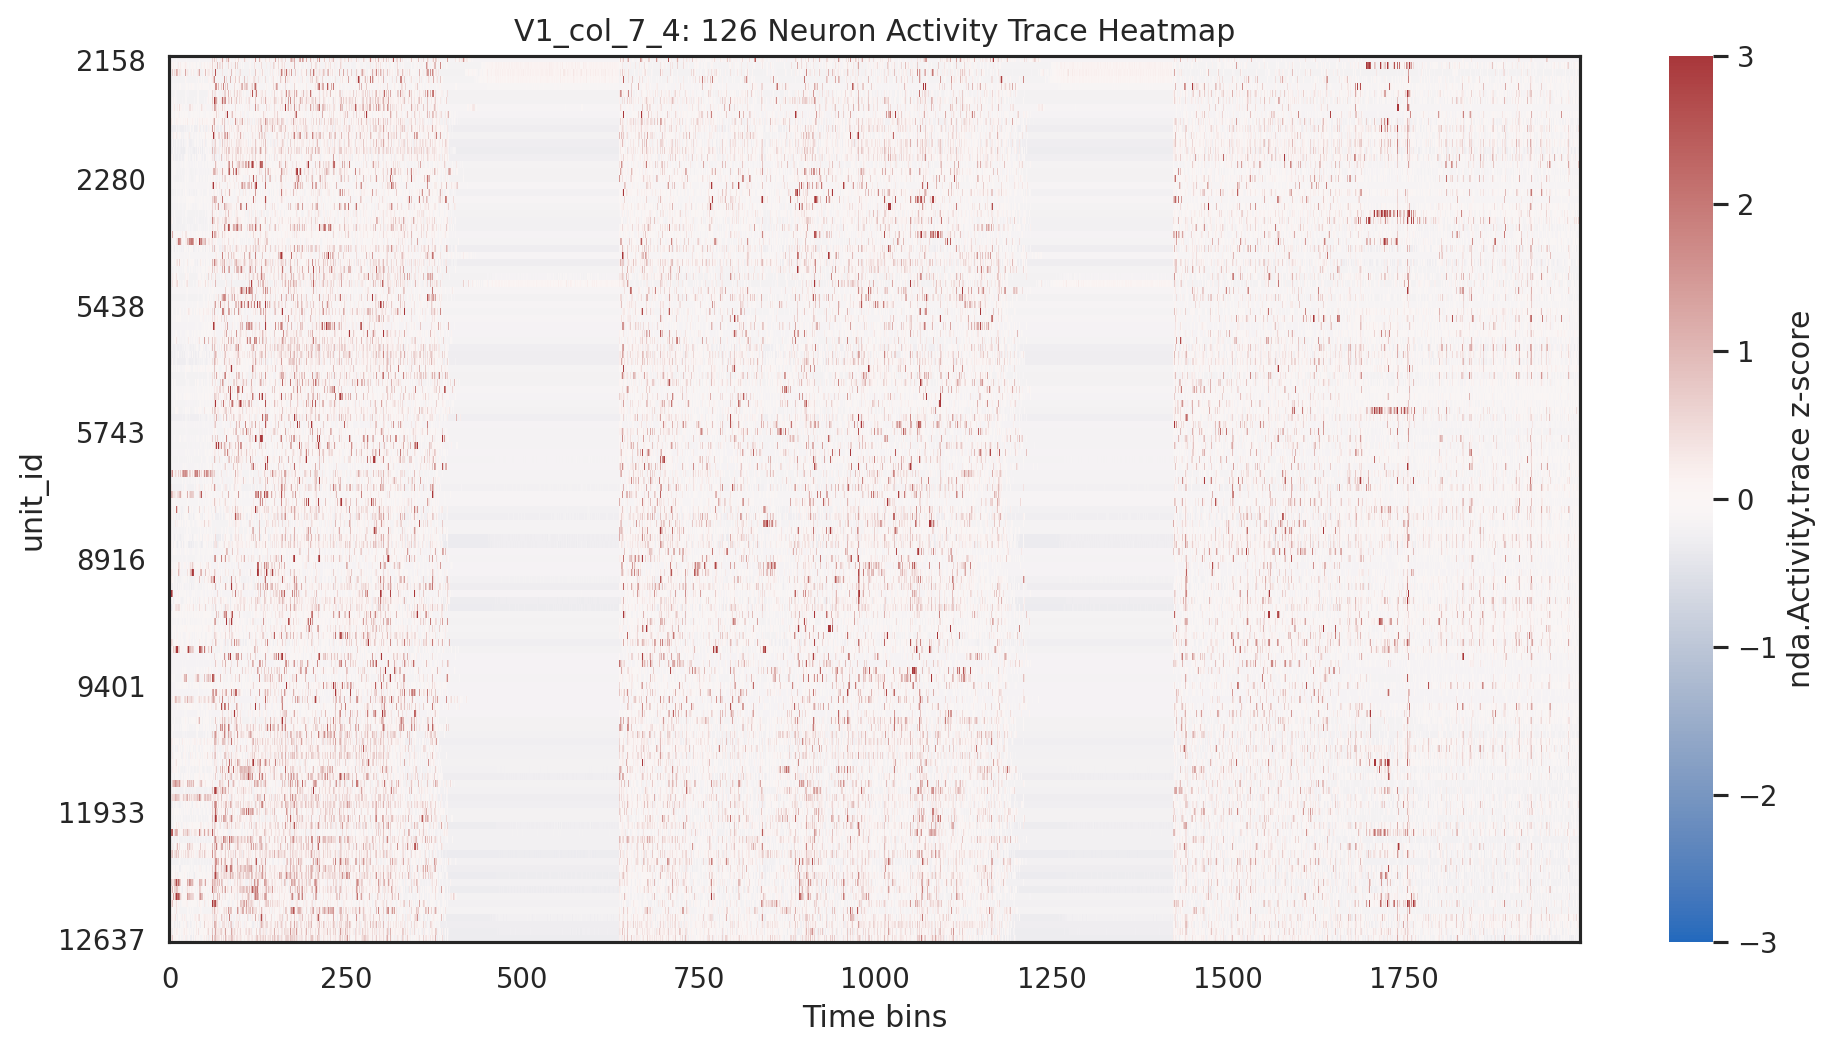

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/example/V1_col_7_4_activity_trace_heatmap.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 6), dpi=180)

im = ax.imshow(
    z_traces_binned,
    aspect="auto",
    cmap="vlag",
    vmin=-3,
    vmax=3,
    interpolation="nearest",
)

ax.set_title("V1_col_7_4: 126 Neuron Activity Trace Heatmap")
ax.set_xlabel("Time bins")
ax.set_ylabel("unit_id")

tick_positions = np.linspace(0, len(plot_unit_ids) - 1, 8, dtype=int)
ax.set_yticks(tick_positions)
ax.set_yticklabels(plot_unit_ids[tick_positions])

cbar = fig.colorbar(im, ax=ax, label="nda.Activity.trace z-score")
cbar.outline.set_linewidth(0)

fig.tight_layout()
fig.savefig(HEATMAP_PATH, bbox_inches="tight")
plt.show()

print("Saved:", HEATMAP_PATH)